# Model 4 - CatBoost

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [59]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

In [60]:
df = pd.read_csv("./datasets/Heart_Disease_Indicators.csv")

In [61]:
X = df.drop(["HeartDiseaseorAttack"], axis=1)
y = df["HeartDiseaseorAttack"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [63]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

In [64]:
train_pool = Pool(X_tr, y_tr)
valid_pool = Pool(X_val, y_val)
test_pool  = Pool(X_test, y_test)

In [65]:
model = CatBoostClassifier(
    loss_function = "Logloss",
    eval_metric = "AUC", # Useful for medical ROC analysis             
    iterations = 2000,
    learning_rate = 0.03,
    depth = 6,
    l2_leaf_reg = 3,
    auto_class_weights = "Balanced",
    random_seed = 42,
    verbose = 200,
    use_best_model = True,
)

In [66]:
model.fit(
    train_pool,
    eval_set = valid_pool,
    early_stopping_rounds = 200,
)

0:	test: 0.8228040	best: 0.8228040 (0)	total: 14.4ms	remaining: 28.8s
200:	test: 0.8524564	best: 0.8524564 (200)	total: 2.3s	remaining: 20.6s
400:	test: 0.8528744	best: 0.8529370 (379)	total: 4.59s	remaining: 18.3s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8529369706
bestIteration = 379

Shrink model to first 380 iterations.


In [67]:
y_prob = model.predict_proba(test_pool)[:, 1]
y_pred_05 = (y_prob >= 0.5).astype(int)

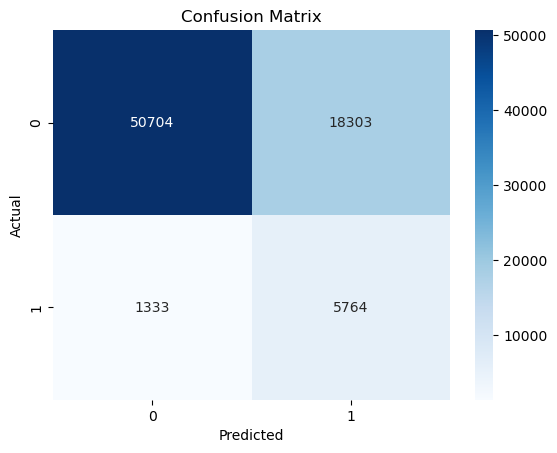

In [68]:
sns.heatmap(confusion_matrix(y_test, y_pred_05), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [69]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

In [70]:
print(f"ROC-AUC: {roc_auc}")
print(f"PR-AUC:  {pr_auc}")

ROC-AUC: 0.8490557221785443
PR-AUC:  0.37559309680112196


In [71]:
print(classification_report(y_test, y_pred_05))

              precision    recall  f1-score   support

         0.0       0.97      0.73      0.84     69007
         1.0       0.24      0.81      0.37      7097

    accuracy                           0.74     76104
   macro avg       0.61      0.77      0.60     76104
weighted avg       0.91      0.74      0.79     76104



In [72]:
prec, rec, thr = precision_recall_curve(y_test, y_prob)

In [73]:
f1_scores = (2 * prec * rec) / (prec + rec + 1e-12)
best_idx = np.argmax(f1_scores)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5  # guard
print(f"Best F1 threshold: {best_thr:.4f}, F1: {f1_scores[best_idx]:.4f}")

Best F1 threshold: 0.7307, F1: 0.4160


In [74]:
y_pred_best = (y_prob >= best_thr).astype(int)
print("\nClassification Report @ best F1 threshold:")
print(classification_report(y_test, y_pred_best, digits=4))


Classification Report @ best F1 threshold:
              precision    recall  f1-score   support

         0.0     0.9472    0.9029    0.9245     69007
         1.0     0.3510    0.5106    0.4160      7097

    accuracy                         0.8663     76104
   macro avg     0.6491    0.7068    0.6703     76104
weighted avg     0.8916    0.8663    0.8771     76104



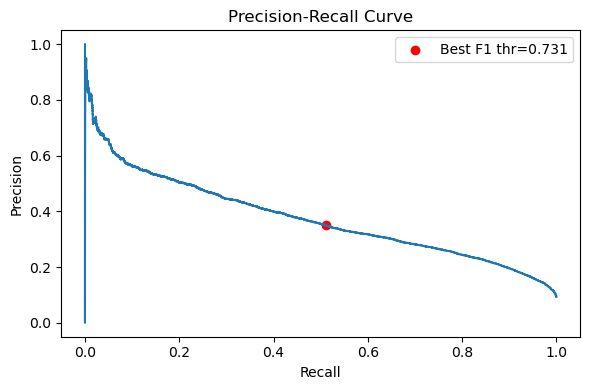

In [75]:
plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.scatter(rec[best_idx], prec[best_idx], color='red', label=f'Best F1 thr={best_thr:.3f}')
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

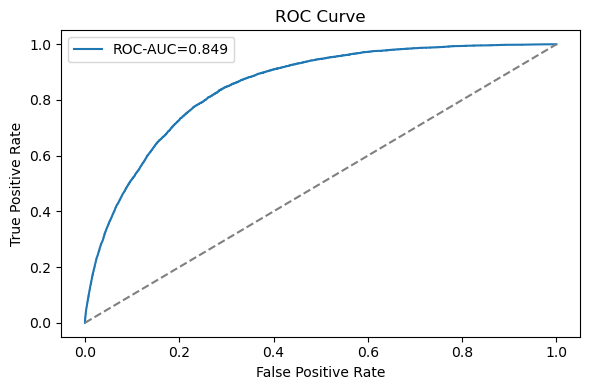

In [76]:
fpr, tpr, roc_thr = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC-AUC={roc_auc:.3f}')
plt.plot([0,1], [0,1], '--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
importances = model.get_feature_importance(train_pool, type="FeatureImportance")
feat_names = X.columns.to_list()

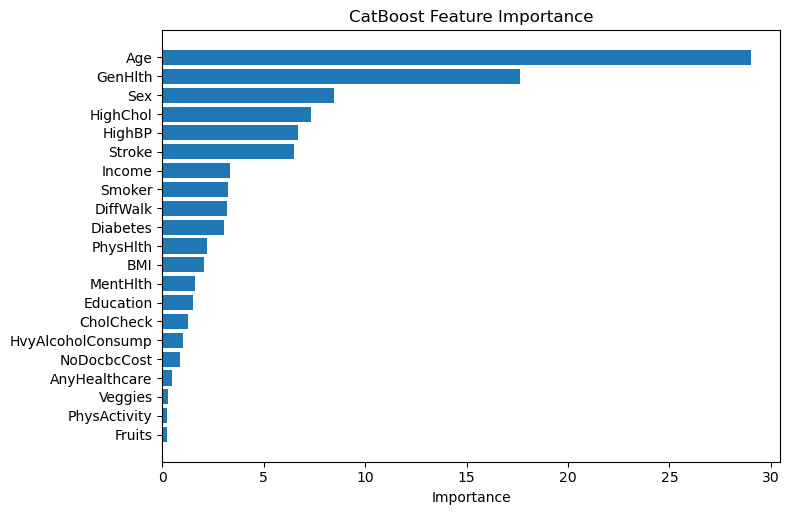

In [78]:
order = np.argsort(importances)[::-1]
plt.figure(figsize=(8, max(4, len(feat_names) * 0.25)))
plt.barh([feat_names[i] for i in order], importances[order])
plt.gca().invert_yaxis()
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Serialization

In [79]:
model.save_model("./model-5.cbm")